# Classification - Default of Credit Card Clients

**Problem statement:** Predict whether a credit card client will default on their payment next month (`default.payment.next.month`) based on demographic attributes, credit data, and payment history.

**Source:** UCI Machine Learning Repository, dataset 350.

## 1. Setup and reproducibility

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
TARGET = "default"
FEATURES = None 

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")

## 2. Dataset loading and audit

In [23]:
data_path = Path("data/classification.csv")

if not data_path.exists():
    data_path = Path("../data/classification.csv")

df = pd.read_csv(data_path)

column_map = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "default",
}

df.rename(
    columns=column_map,
    inplace=True
)

assert TARGET in df.columns, f"'{TARGET}' not found. Columns: {df.columns.tolist()}"

FEATURES = [
    c for c in df.columns if c not in (
        "ID",
        TARGET
    )
]

print(f"Shape: {df.shape}")
display(df.head())

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [24]:
audit = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean().mul(100).round(2),
        "unique_values": df.nunique(),
    }
)

display(audit)

print(f"Duplicate rows: {df.duplicated().sum()}")

,dtype,missing_count,missing_percent,unique_values
LIMIT_BAL,int64,0,0.0,81
SEX,int64,0,0.0,2
EDUCATION,int64,0,0.0,7
MARRIAGE,int64,0,0.0,4
AGE,int64,0,0.0,56
PAY_0,int64,0,0.0,11
PAY_2,int64,0,0.0,11
PAY_3,int64,0,0.0,11
PAY_4,int64,0,0.0,11
PAY_5,int64,0,0.0,10


Duplicate rows: 35


In [25]:
display(df.describe().T)
display(df[TARGET].value_counts(normalize=True).mul(100).round(2).to_frame("target_distribution_%"))

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


,target_distribution_%
default,
0,77.88
1,22.12


### Audit observation

The dataset contains 30,000 observations, 23 predictors, and one binary target, all loading as `int64`/`float64` with no missing values. There are 0 exact duplicate rows. `EDUCATION` and `MARRIAGE` contain undocumented category codes (0, 5, 6 and 0 respectively) that will need consolidating. The target `default` is imbalanced at 77.9% (0) vs 22.1% (1).

# 3. Exploratory data analysis

## Target distribution

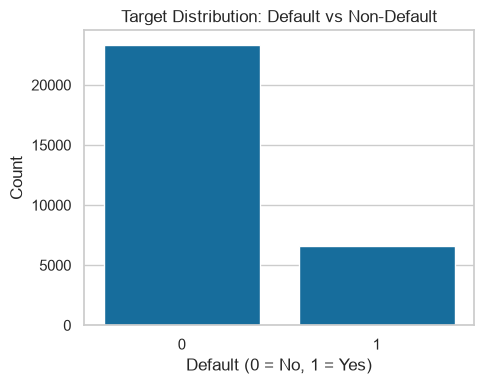

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=TARGET, data=df, ax=ax)
ax.set(title="Target Distribution: Default vs Non-Default", xlabel="Default (0 = No, 1 = Yes)", ylabel="Count")
plt.tight_layout()
plt.show()

**Observation:** The target is imbalanced — roughly 78% of clients did not default (0) versus 22% who did (1). This means accuracy alone would be misleading, so weighted F1, confusion matrices, and a stratified train/test split will be used throughout.

## Feature distributions

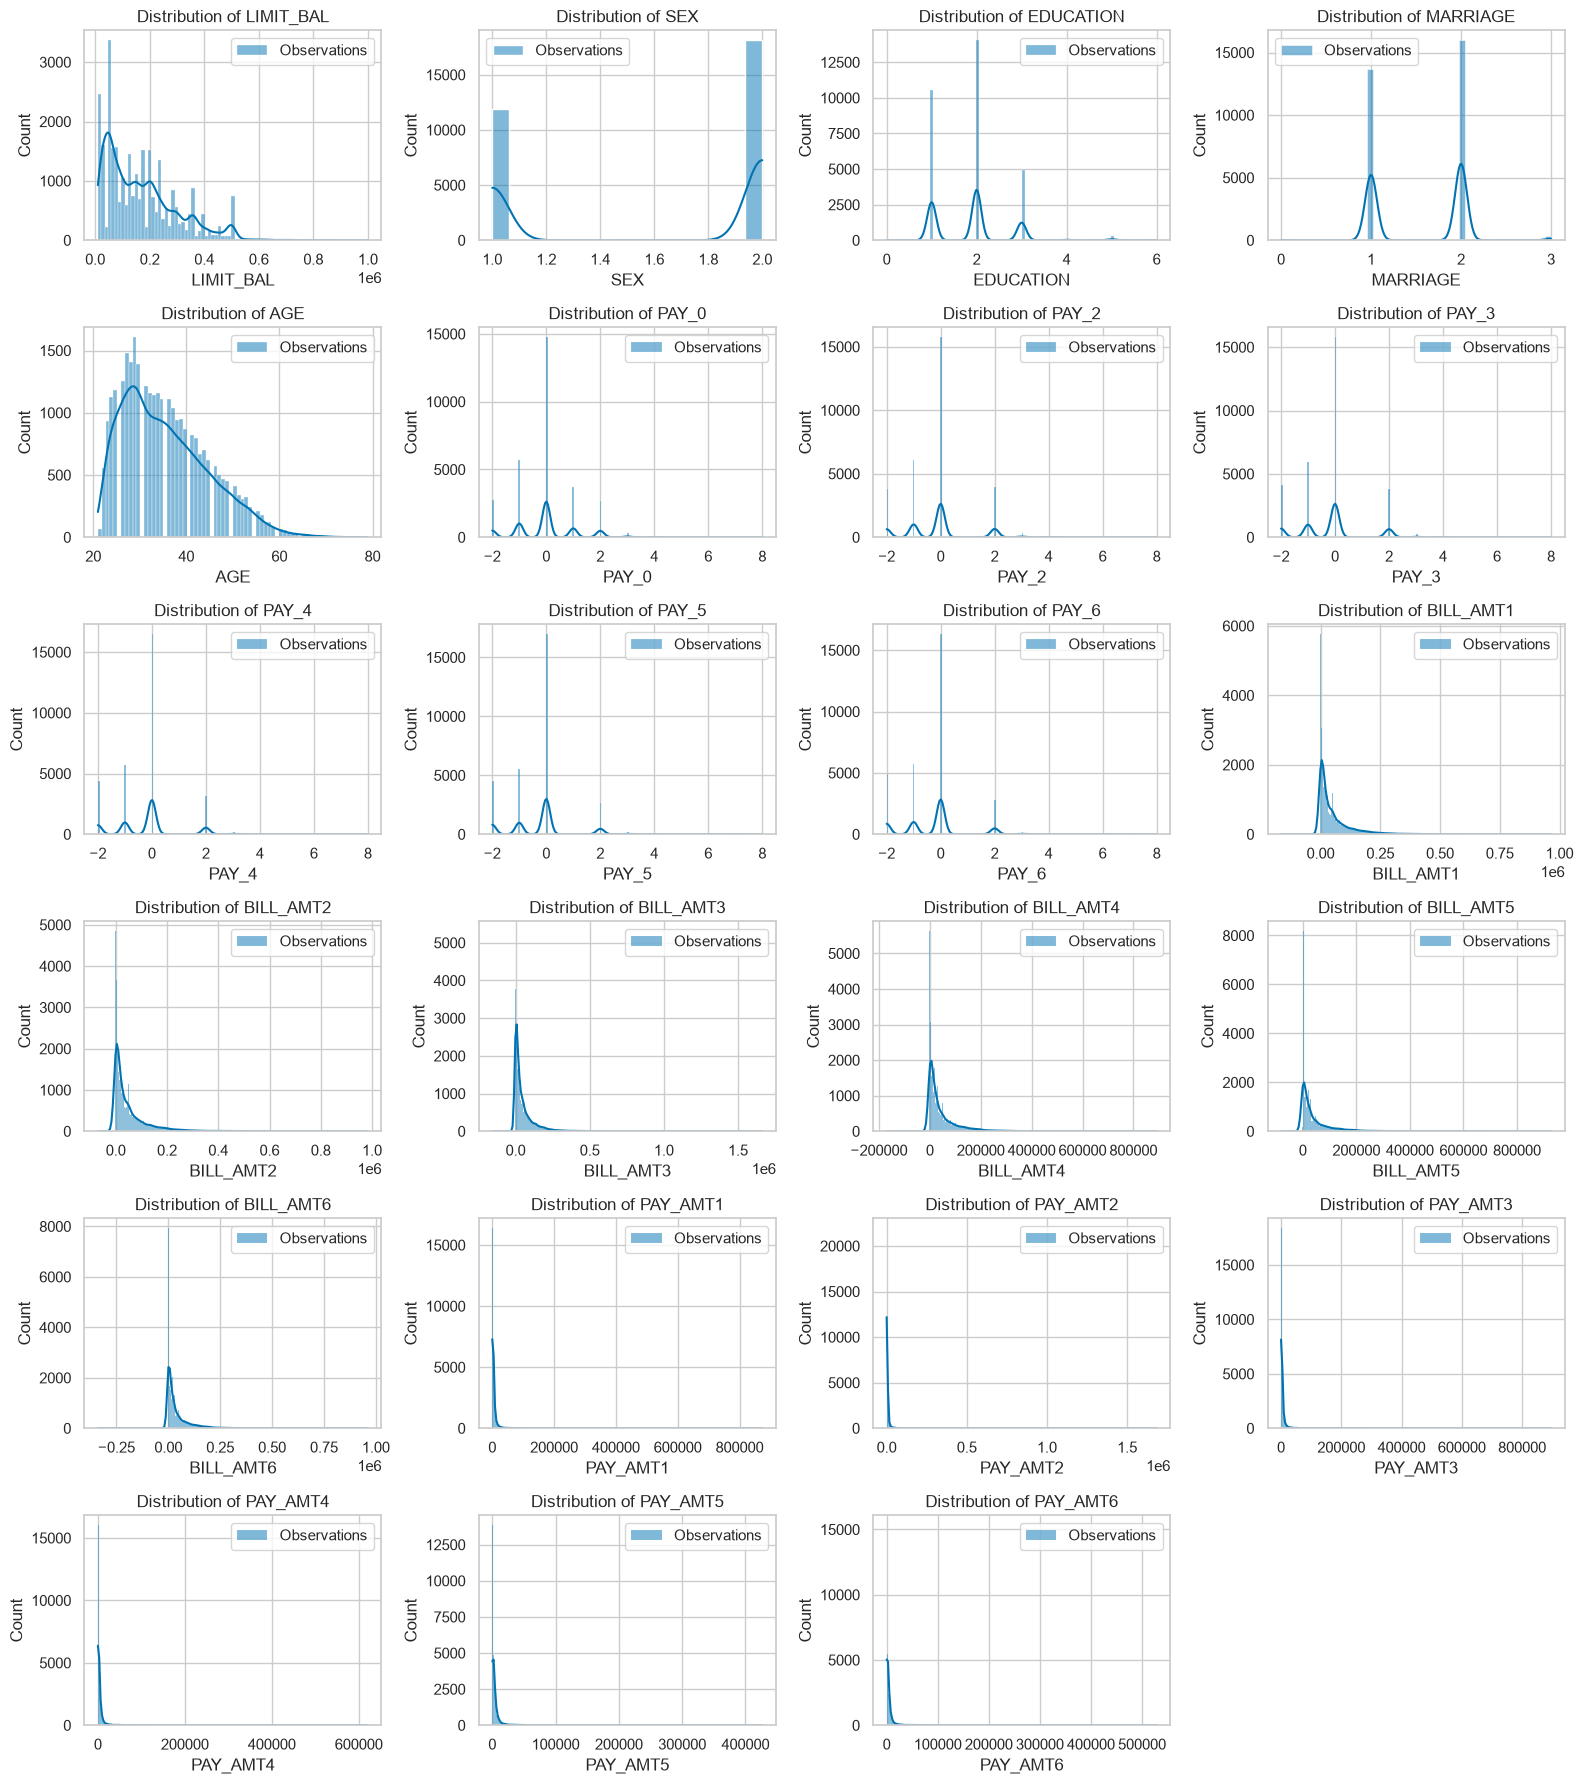

In [34]:
n_cols = 4
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

for feature, axis in zip(FEATURES, axes.flat):
    sns.histplot(df[feature], kde=True, label="Observations", ax=axis)
    axis.set(title=f"Distribution of {feature}", xlabel=feature, ylabel="Count")
    axis.legend()

for axis in axes.flat[len(FEATURES):]:
    axis.set_visible(False)

plt.tight_layout()

**Observation:** Most monetary columns (`LIMIT_BAL`, `BILL_AMT1`–`BILL_AMT6`, `PAY_AMT1`–`PAY_AMT6`) are heavily right-skewed, with a long tail of high-value clients and a mass near zero; some `BILL_AMT` columns also contain negative values (overpayments/credits). `AGE` is mildly right-skewed, concentrated between 25–45. `SEX`, `EDUCATION`, and `MARRIAGE` are categorical codes rather than continuous distributions, and `EDUCATION`/`MARRIAGE` show unexpected categories (0, 5, 6) beyond their documented range, consistent with the audit findings. `PAY_0`–`PAY_6` cluster heavily around 0 and -1 (on-time/duly-paid), with a smaller spread of positive values indicating payment delay in months.

## Correlation heatmap

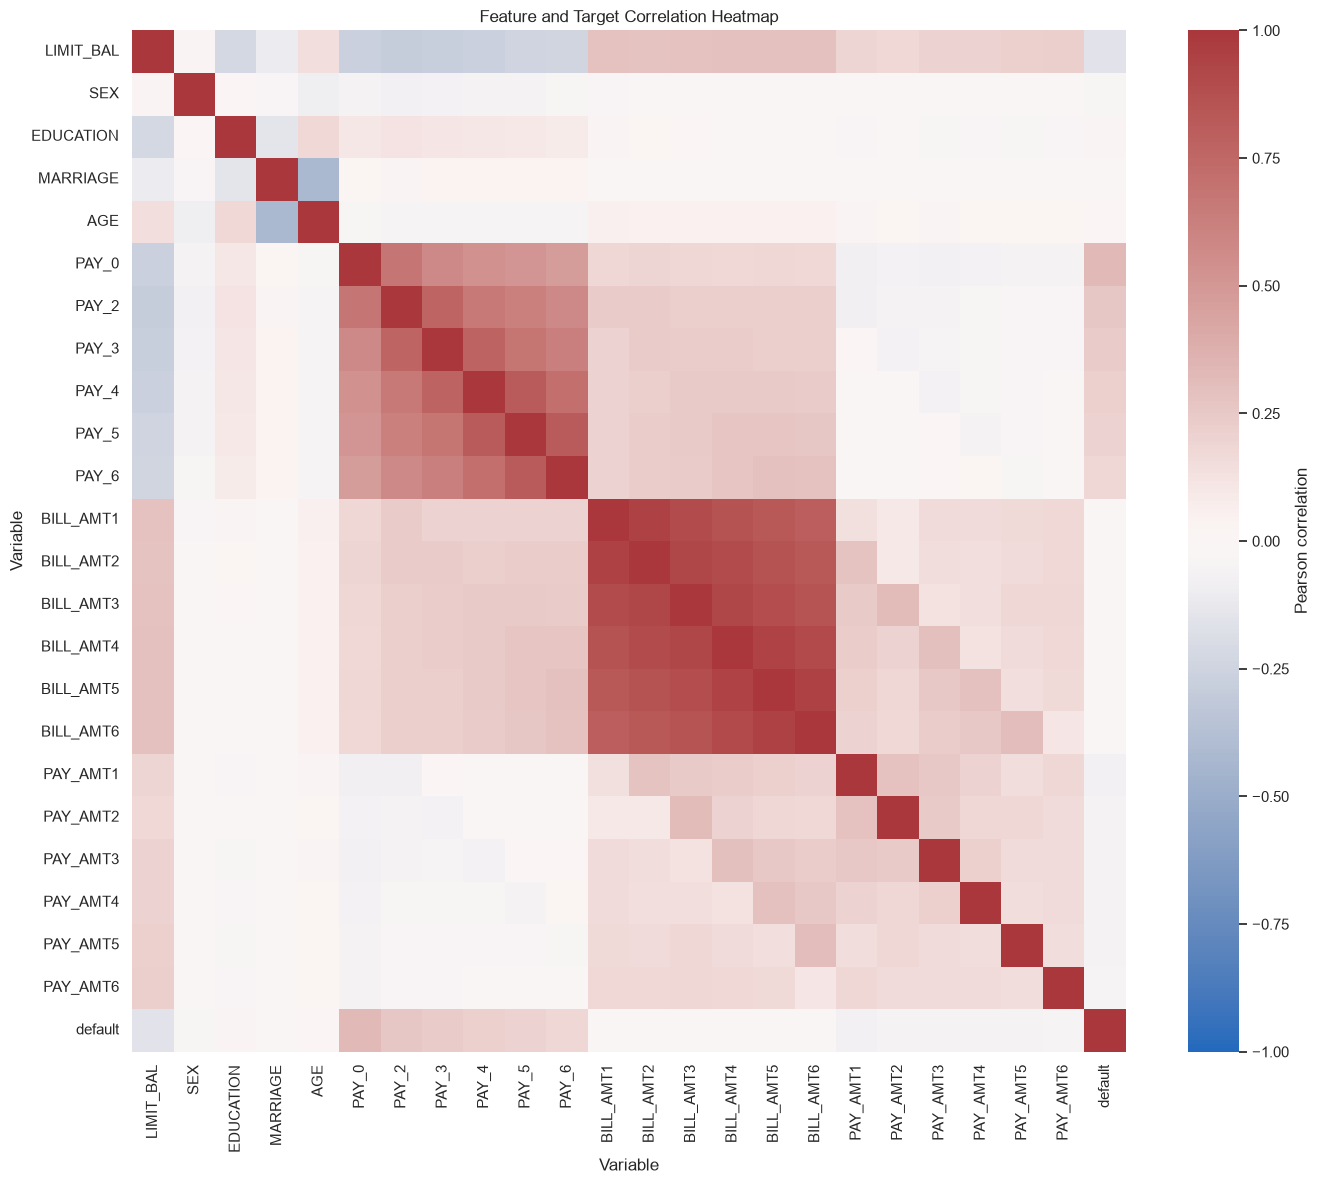

In [35]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), annot=False, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, cbar_kws={"label": "Pearson correlation"})
plt.title("Feature and Target Correlation Heatmap")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.tight_layout()

**Observation:** `PAY_0` through `PAY_6` show the strongest positive correlation with `default`, consistent with recent repayment history being the most predictive signal. `BILL_AMT1`–`BILL_AMT6` are highly correlated with each other (multicollinear, as expected for consecutive monthly bills), which tree-based models handle natively but which may need addressing for linear models like Logistic Regression. `LIMIT_BAL` shows a mild negative correlation with `default`. Demographic features (`SEX`, `AGE`, `EDUCATION`, `MARRIAGE`) show weak correlation with the target individually.

## Feature target relationships

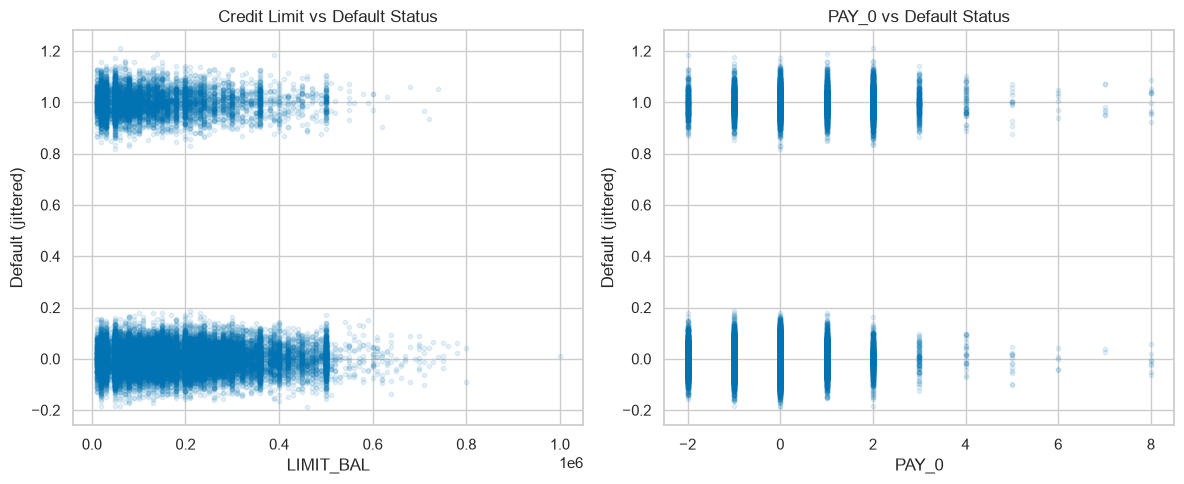

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

jitter = np.random.normal(0, 0.05, size=len(df))

axes[0].scatter(df["LIMIT_BAL"], df[TARGET] + jitter, alpha=0.1, s=10)
axes[0].set(title="Credit Limit vs Default Status", xlabel="LIMIT_BAL", ylabel="Default (jittered)")

axes[1].scatter(df["PAY_0"], df[TARGET] + jitter, alpha=0.1, s=10)
axes[1].set(title="PAY_0 vs Default Status", xlabel="PAY_0", ylabel="Default (jittered)")

plt.tight_layout()

**Observation:** Since `default` is binary, points are jittered vertically to reveal density. Clients with lower `LIMIT_BAL` show a visibly denser cluster near default = 1, though overlap with non-defaulters is substantial. `PAY_0` shows a much sharper pattern — higher (more delayed) values are almost exclusively associated with default = 1, confirming it as one of the strongest individual predictors.